# Basic Machine Learning Pipeline

This demo turns the supervised learning workflow into a sequence of small PyTorch components: data, model, loss, optimizer, training loop, and diagnostics. The goal is not to introduce a new inverse-problem algorithm, but to make the standard machine-learning pipeline explicit enough to reuse later in inverse problems and data assimilation.

See Chapter 12, Section 12.1: Notational Conventions; Chapter 12, Section 12.2: Neural Networks; and Chapter 15, Section 15.1: Gradient Descent.

We use two examples:

- a one-dimensional regression problem, where the fitted function can be inspected directly;
- an MNIST classification problem, where a learned feature space is inspected with UMAP.


## Supervised learning notation

A supervised dataset consists of pairs $\{(x_i,y_i)\}_{i=1}^N$. A neural network $h_\theta$ maps inputs to predictions $\hat y_i = h_\theta(x_i)$, where $\theta$ denotes all trainable weights and biases. Training chooses $\theta$ by approximately minimizing an empirical risk,

$$
\mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^N \ell(h_\theta(x_i), y_i),
$$

using stochastic gradients computed on mini-batches. The same workflow appears throughout scientific machine learning: define data, choose a model class, choose an objective, optimize, and diagnose the result.


In [14]:
#@title Imports and shared utilities
import hashlib
import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import HTML, display
from matplotlib import animation
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split

warnings.filterwarnings("ignore")


def set_all_seeds(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def stable_config_hash(config):
    text = json.dumps(config, sort_keys=True, default=str)
    return hashlib.sha1(text.encode("utf-8")).hexdigest()[:10]


def load_checkpoint(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def save_checkpoint(payload, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, path)


## Data: a chirp regression problem

For the first example, the input is a scalar $x\in[-1,1]$ and the observation model is

$$
y_i = f(x_i) + \epsilon_i, \qquad f(x)=\sin(10\pi x^2), \qquad \epsilon_i\sim \mathcal{N}(0,\sigma^2).
$$

A `Dataset` provides individual samples to a `DataLoader`, which forms mini-batches for stochastic optimization. The custom dataset below also demonstrates two common data-pipeline ideas.

- **Augmentation:** since $f(x)=f(-x)$, randomly replacing $x$ by $-x$ encodes a known symmetry.
- **Sample weights:** the chirp oscillates faster near $|x|=1$, so the weight $w(x)=1+2|x|^2$ emphasizes the harder edge regions in the weighted mean squared error.


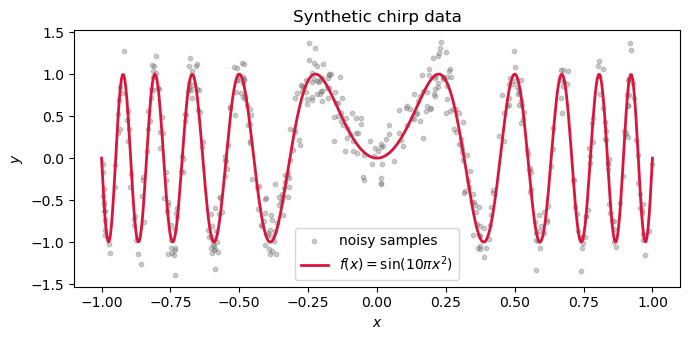

In [15]:
#@title Chirp data utilities

def generate_chirp_data(n_samples=1000, noise_level=0.1, seed=42):
    set_all_seeds(seed)
    x = 2.0 * torch.rand(n_samples, 1) - 1.0
    y_true = torch.sin(10.0 * torch.pi * x**2)
    y = y_true + noise_level * torch.randn_like(y_true)
    return x, y


class ChirpDataset(Dataset):
    def __init__(self, x, y, augment=False, return_weights=False):
        self.x = x
        self.y = y
        self.augment = augment
        self.return_weights = return_weights

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x = self.x[idx]
        y = self.y[idx]
        if self.augment and torch.rand(()) < 0.5:
            x = -x
        if self.return_weights:
            weight = 1.0 + 2.0 * torch.abs(x) ** 2
            return x, y, weight
        return x, y


def make_chirp_loaders(config):
    x_full, y_full = generate_chirp_data(
        n_samples=config["n_samples"],
        noise_level=config["noise_level"],
        seed=config["seed"],
    )
    full_dataset = TensorDataset(x_full, y_full)
    train_size = int(0.8 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    generator = torch.Generator().manual_seed(config["seed"])
    train_subset, test_subset = random_split(full_dataset, [train_size, test_size], generator=generator)

    x_train, y_train = x_full[train_subset.indices], y_full[train_subset.indices]
    x_test, y_test = x_full[test_subset.indices], y_full[test_subset.indices]

    train_ds = ChirpDataset(
        x_train,
        y_train,
        augment=config["use_augmentation"],
        return_weights=config["use_weights"],
    )
    test_ds = ChirpDataset(x_test, y_test, augment=False, return_weights=False)
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=config["batch_size"], shuffle=False)
    return train_loader, test_loader, (x_full, y_full, x_train, y_train, x_test, y_test)


x_preview, y_preview = generate_chirp_data(n_samples=500, noise_level=0.2)
x_grid_preview = torch.linspace(-1, 1, 500).unsqueeze(1)
y_grid_preview = torch.sin(10 * torch.pi * x_grid_preview**2)
plt.figure(figsize=(7, 3.5))
plt.scatter(x_preview, y_preview, s=10, alpha=0.35, color="0.45", label="noisy samples")
plt.plot(x_grid_preview, y_grid_preview, color="crimson", lw=2, label=r"$f(x)=\sin(10\pi x^2)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Synthetic chirp data")
plt.legend()
plt.tight_layout()
plt.show()


## Model: a configurable multilayer perceptron

A multilayer perceptron (MLP) is a composition of affine maps and nonlinear activation functions. In this notebook, `hidden_dim` is the width of each hidden layer, `num_hidden_layers` is the depth before the output layer, and `activation` is the nonlinear function between linear layers. The output layer is left linear because this is a regression problem.


In [16]:
#@title MLP model definition
class FlexibleMLP(nn.Module):
    def __init__(self, input_dim=1, output_dim=1, hidden_dim=128, num_hidden_layers=3, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), activation()]
        for _ in range(num_hidden_layers - 1):
            layers.extend([nn.Linear(hidden_dim, hidden_dim), activation()])
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model_example = FlexibleMLP(hidden_dim=32, num_hidden_layers=2, activation=nn.Tanh)
print(model_example)


FlexibleMLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Objective and optimizer

For regression, the mean squared error compares predictions $\hat y_i$ to targets $y_i$:

$$
\mathrm{MSE} = \frac{1}{B}\sum_{i=1}^B (\hat y_i-y_i)^2,
$$

where $B$ is the mini-batch size. A weighted version replaces each term by $w_i(\hat y_i-y_i)^2$. The optimizer updates $\theta$ using gradients from automatic differentiation. For stochastic gradient descent with learning rate $\eta$,

$$
\theta_{k+1}=\theta_k-\eta\nabla_\theta \mathcal{L}(\theta_k).
$$

Adam and AdamW adapt the step size per parameter and are often good defaults for neural networks.


In [17]:
#@title Loss and optimizer utilities
class WeightedMSELoss(nn.Module):
    def forward(self, prediction, target, weight=None):
        loss = (prediction - target) ** 2
        if weight is not None:
            loss = loss * weight
        return loss.mean()


def get_optimizer(model, optimizer_type="AdamW", learning_rate=1e-3, weight_decay=0.0, momentum=0.9):
    if optimizer_type == "Adam":
        return optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    if optimizer_type == "AdamW":
        return optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    if optimizer_type == "SGD":
        return optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer type: {optimizer_type}")


criterion_example = WeightedMSELoss()
print("Example loss:", criterion_example(torch.tensor([[1.0]]), torch.tensor([[0.25]])).item())


Example loss: 0.5625


## Experiment 1: fitting the chirp function

The training loop repeats the same four steps: compute predictions, evaluate the loss, call `backward()` to compute gradients, and call `step()` to update parameters. The plots show training loss, test MSE, and the learned function on a dense grid.

**Parameter exploration.**

- Adjust `activation_type`. `ReLU` is piecewise linear and not smooth enough for this oscillatory target, while `Tanh` can be limited by its bounded output range and saturation; `GELU` often gives the best compromise here.
- Adjust `use_weights`. Turning it on emphasizes the high-frequency edge regions; turning it off treats all samples equally and may fit the middle of the interval more easily.
- Adjust `hidden_dim` and `num_hidden_layers`. Smaller networks tend to underfit and miss oscillations, while larger networks can resolve more detail but may need more data or training time.
- Adjust `noise_level`. Smaller noise makes the target easier to identify, while larger noise makes the fitted curve a smoother compromise through the observations.

**Recommended test combinations.** Keep the other parameters at their displayed defaults and compare the learned curve, train loss, and test MSE.

| Exp ID | Activation | Weights? | Augmentation? | Architecture |
| :--- | :--- | :---: | :---: | :--- |
| **1** | Tanh | ❌ | ❌ | 3 layers / 128 |
| **2** | ReLU | ❌ | ❌ | 3 layers / 128 |
| **3** | GELU | ❌ | ❌ | 3 layers / 128 |
| **4** | GELU | ✅ | ❌ | 3 layers / 128 |
| **5** | GELU | ✅ | ✅ | 3 layers / 128 |
| **6** | GELU | ✅ | ✅ | 4 layers / 128 |

The cell saves a checkpoint keyed by the training configuration. If the same configuration is run again, the saved histories and model state are loaded automatically.


Running on cuda. Checkpoint: checkpoints/chirp_fit_65a720c265.pt
Loaded checkpoint; training skipped.


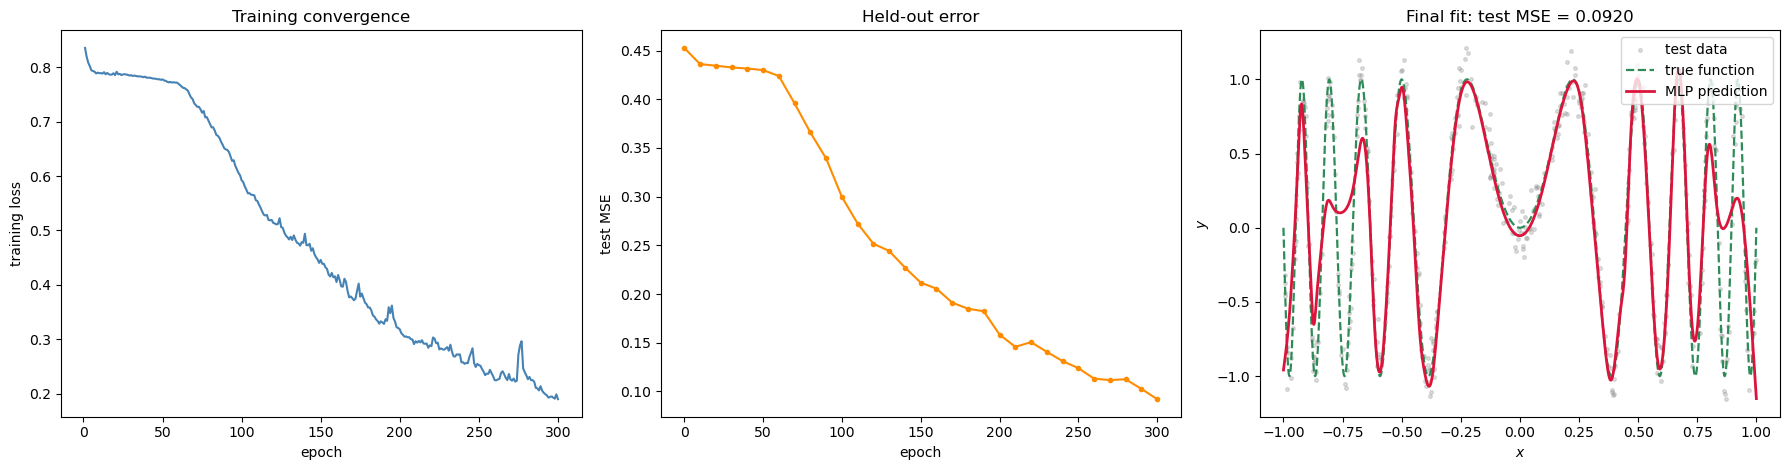

Generating fit animation from saved snapshots...


In [18]:
#@title Chirp fitting experiment
CHIRP_DEFAULTS = {
    "seed": 42,
    "n_samples": 2500,
    "noise_level": 0.10,
    "use_augmentation": False,
    "use_weights": True,
    "hidden_dim": 128,
    "num_hidden_layers": 3,
    "activation_type": "GELU",
    "optimizer_type": "AdamW",
    "learning_rate": 0.002,
    "weight_decay": 1e-4,
    "momentum": 0.9,
    "num_epochs": 300,
    "batch_size": 512,
    "test_interval": 10,
}

use_default = False #@param {type:"boolean"}
n_samples = 2500 #@param {type:"slider", min:500, max:5000, step:100}
noise_level = 0.10 #@param {type:"slider", min:0.0, max:0.5, step:0.05}
activation_type = "GELU" #@param ["Tanh", "ReLU", "GELU"]
use_weights = True #@param {type:"boolean"}
use_augmentation = False #@param {type:"boolean"}
hidden_dim = 128 #@param {type:"slider", min:16, max:256, step:16}
num_hidden_layers = 3 #@param {type:"slider", min:1, max:8, step:1}
learning_rate = 0.002 #@param {type:"number"}
num_epochs = 300 #@param {type:"slider", min:50, max:800, step:50}
batch_size = 512 #@param {type:"slider", min:64, max:2048, step:64}
show_animation = True #@param {type:"boolean"}
force_retrain = False #@param {type:"boolean"}

chirp_config = CHIRP_DEFAULTS.copy()
if not use_default:
    chirp_config.update({
        "n_samples": int(n_samples),
        "noise_level": float(noise_level),
        "activation_type": activation_type,
        "use_weights": bool(use_weights),
        "use_augmentation": bool(use_augmentation),
        "hidden_dim": int(hidden_dim),
        "num_hidden_layers": int(num_hidden_layers),
        "learning_rate": float(learning_rate),
        "num_epochs": int(num_epochs),
        "batch_size": int(batch_size),
    })

chirp_key = stable_config_hash(chirp_config)
chirp_checkpoint = Path("checkpoints") / f"chirp_fit_{chirp_key}.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}. Checkpoint: {chirp_checkpoint}")

if chirp_checkpoint.exists() and not force_retrain:
    payload = load_checkpoint(chirp_checkpoint, map_location="cpu")
    print("Loaded checkpoint; training skipped.")
else:
    set_all_seeds(chirp_config["seed"])
    train_loader, test_loader, chirp_tensors = make_chirp_loaders(chirp_config)
    x_full, y_full, x_train, y_train, x_test, y_test = chirp_tensors

    activation_map = {"Tanh": nn.Tanh, "ReLU": nn.ReLU, "GELU": nn.GELU}
    model = FlexibleMLP(
        hidden_dim=chirp_config["hidden_dim"],
        num_hidden_layers=chirp_config["num_hidden_layers"],
        activation=activation_map[chirp_config["activation_type"]],
    ).to(device)
    optimizer = get_optimizer(
        model,
        optimizer_type=chirp_config["optimizer_type"],
        learning_rate=chirp_config["learning_rate"],
        weight_decay=chirp_config["weight_decay"],
        momentum=chirp_config["momentum"],
    )
    criterion = WeightedMSELoss()
    x_grid = torch.linspace(-1, 1, 1000).unsqueeze(1).to(device)
    y_grid_true = torch.sin(10 * torch.pi * x_grid**2).cpu().numpy()

    def evaluate_chirp(epoch):
        model.eval()
        losses = []
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                losses.append(criterion(model(x_batch), y_batch).item())
            y_grid_pred = model(x_grid).cpu().numpy()
        return {"epoch": epoch, "test_mse": float(np.mean(losses)), "grid_prediction": y_grid_pred}

    train_loss_history = []
    test_history = [evaluate_chirp(0)]
    print(f"Data: {len(train_loader.dataset)} train samples, {len(test_loader.dataset)} test samples")
    print("Starting training...")

    for epoch in range(1, chirp_config["num_epochs"] + 1):
        model.train()
        epoch_loss = 0.0
        for batch in train_loader:
            if chirp_config["use_weights"]:
                x_batch, y_batch, weights = batch
                x_batch, y_batch, weights = x_batch.to(device), y_batch.to(device), weights.to(device)
            else:
                x_batch, y_batch = batch
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                weights = None
            optimizer.zero_grad()
            loss = criterion(model(x_batch), y_batch, weights)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_loss_history.append(epoch_loss / len(train_loader))
        if epoch % chirp_config["test_interval"] == 0 or epoch == chirp_config["num_epochs"]:
            test_history.append(evaluate_chirp(epoch))
        if epoch % max(1, chirp_config["num_epochs"] // 5) == 0:
            print(f"Epoch {epoch:4d}/{chirp_config['num_epochs']} | train loss {train_loss_history[-1]:.6f} | test MSE {test_history[-1]['test_mse']:.6f}")

    payload = {
        "config": chirp_config,
        "model_state": model.cpu().state_dict(),
        "train_loss_history": train_loss_history,
        "test_history": test_history,
        "x_full": x_full,
        "y_full": y_full,
        "x_test": x_test,
        "y_test": y_test,
        "x_grid": x_grid.cpu(),
        "y_grid_true": y_grid_true,
    }
    save_checkpoint(payload, chirp_checkpoint)
    print("Saved checkpoint.")

cfg = payload["config"]
train_loss_history = payload["train_loss_history"]
test_history = payload["test_history"]
x_full = payload["x_full"].detach().cpu()
y_full = payload["y_full"].detach().cpu()
x_test = payload["x_test"].detach().cpu()
y_test = payload["y_test"].detach().cpu()
x_grid = payload["x_grid"].detach().cpu()
y_grid_true = payload["y_grid_true"]
final_prediction = test_history[-1]["grid_prediction"]

test_epochs = [item["epoch"] for item in test_history]
test_errors = [item["test_mse"] for item in test_history]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
axes[0].plot(range(1, len(train_loss_history) + 1), train_loss_history, color="steelblue")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("Training convergence")

axes[1].plot(test_epochs, test_errors, color="darkorange", marker="o", ms=3)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("test MSE")
axes[1].set_title("Held-out error")

axes[2].scatter(x_test.numpy(), y_test.numpy(), s=7, color="0.5", alpha=0.25, label="test data")
axes[2].plot(x_grid.numpy(), y_grid_true, "--", color="seagreen", lw=1.6, label="true function")
axes[2].plot(x_grid.numpy(), final_prediction, color="crimson", lw=2.0, label="MLP prediction")
axes[2].set_xlabel(r"$x$")
axes[2].set_ylabel(r"$y$")
axes[2].set_title(f"Final fit: test MSE = {test_errors[-1]:.4f}")
axes[2].legend(loc="upper right")
plt.tight_layout()
plt.show()

if show_animation:
    print("Generating fit animation from saved snapshots...")
    fig_anim, (ax_fit, ax_train, ax_test) = plt.subplots(1, 3, figsize=(18, 4.8))
    ax_fit.scatter(x_test.numpy(), y_test.numpy(), s=7, color="0.5", alpha=0.20)
    ax_fit.plot(x_grid.numpy(), y_grid_true, "--", color="seagreen", lw=1.5)
    fit_line, = ax_fit.plot([], [], color="crimson", lw=2)
    ax_fit.set_xlim(-1, 1)
    ax_fit.set_ylim(float(y_full.min()) - 0.4, float(y_full.max()) + 0.4)
    ax_fit.set_title("Function fit")

    ax_train.set_xlim(0, cfg["num_epochs"])
    ax_train.set_ylim(min(train_loss_history) * 0.8, max(train_loss_history) * 1.2)
    ax_train.set_title("Training loss")
    train_line, = ax_train.plot([], [], color="steelblue")
    train_dot, = ax_train.plot([], [], "o", color="steelblue")

    ax_test.set_xlim(0, cfg["num_epochs"])
    ax_test.set_ylim(min(test_errors) * 0.8, max(test_errors) * 1.2)
    ax_test.set_title("Test MSE")
    test_line, = ax_test.plot([], [], color="darkorange")
    test_dot, = ax_test.plot([], [], "o", color="darkorange")

    def animate_chirp(i):
        item = test_history[i]
        epoch = item["epoch"]
        fit_line.set_data(x_grid.numpy(), item["grid_prediction"])
        train_line.set_data(range(1, epoch + 1), train_loss_history[:epoch])
        if epoch > 0:
            train_dot.set_data([epoch], [train_loss_history[epoch - 1]])
        current_test = test_history[: i + 1]
        current_epochs = [entry["epoch"] for entry in current_test]
        current_errors = [entry["test_mse"] for entry in current_test]
        test_line.set_data(current_epochs, current_errors)
        test_dot.set_data([current_epochs[-1]], [current_errors[-1]])
        fig_anim.suptitle(f"Chirp regression training: epoch {epoch}")
        return fit_line, train_line, train_dot, test_line, test_dot

    anim = animation.FuncAnimation(fig_anim, animate_chirp, frames=len(test_history), interval=180, blit=False)
    plt.close(fig_anim)
    display(HTML(anim.to_jshtml()))


## High-dimensional diagnostics: MNIST features and UMAP

In the chirp example, model behavior can be plotted directly because $x$ is one-dimensional. For image data, the input lives in $\mathbb{R}^{28\times 28}$, so diagnostics usually summarize either scalar metrics or learned representations.

MNIST is a ten-class handwritten digit classification dataset. The convolutional neural network below maps an image to a feature vector and then to class logits. The training loss is cross entropy, and test accuracy is the fraction of held-out images classified correctly.

UMAP, short for Uniform Manifold Approximation and Projection, embeds high-dimensional feature vectors in two dimensions. If the classifier learns useful features, points with the same digit label should tend to form separated clusters in the UMAP plot.

**Parameter exploration.**

- Adjust `data_fraction`. Smaller fractions run faster but give noisier accuracy and less stable clusters; larger fractions give a more reliable learning signal.
- Adjust `num_epochs`. Fewer epochs show early, weakly organized features; more epochs usually make accuracy and class separation improve until they saturate.
- Adjust `umap_num_points`. Fewer points make UMAP faster; more points give a more representative view of the learned feature space.

**Recommended learning-rate tests.** Keep `data_fraction = 0.30` for a quick comparison and keep `num_epochs` at or below 16 so the runs stay short.

| Exp ID | Learning rate | Epochs | What to look for |
| :--- | :---: | :---: | :--- |
| **1** | 0.001 | 8 | Slow but steady learning; UMAP clusters may still be loose. |
| **2** | 0.003 | 8 | Faster improvement with usually stable loss. |
| **3** | 0.010 | 8 | Good default speed; accuracy should rise quickly. |
| **4** | 0.010 | 16 | Same step size with more training; class clusters should become clearer. |

The MNIST experiment also uses a configuration-keyed checkpoint, so repeated runs with the same training settings reuse saved losses, accuracies, and feature snapshots.


In [19]:
#@title Optional dependency for UMAP
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("umap") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "umap-learn"])

import umap


In [20]:
#@title MNIST model and data helpers
import torch.nn.functional as F
from torch.utils.data import Subset
from torchvision import datasets, transforms


class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.flat_dim = 16 * 7 * 7
        self.fc = nn.Linear(self.flat_dim, num_classes)

    def get_features(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        return x.reshape(-1, self.flat_dim)

    def forward(self, x):
        return self.fc(self.get_features(x))


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def dataset_targets(dataset):
    if isinstance(dataset, Subset):
        return torch.as_tensor(dataset.dataset.targets)[dataset.indices]
    return torch.as_tensor(dataset.targets)


def stratified_subset(dataset, fraction, seed=42, num_classes=10):
    targets = dataset_targets(dataset)
    generator = torch.Generator().manual_seed(seed)
    selected = []
    for label in range(num_classes):
        class_positions = (targets == label).nonzero(as_tuple=True)[0]
        keep = max(1, int(len(class_positions) * fraction))
        perm = torch.randperm(len(class_positions), generator=generator)
        selected.append(class_positions[perm[:keep]])
    return Subset(dataset, torch.cat(selected).tolist())


def balanced_subset(dataset, num_samples=1000, num_classes=10):
    targets = dataset_targets(dataset)
    per_class = max(1, num_samples // num_classes)
    selected = []
    for label in range(num_classes):
        positions = (targets == label).nonzero(as_tuple=True)[0]
        selected.append(positions[:per_class])
    return Subset(dataset, torch.cat(selected).tolist())


In [21]:
#@title MNIST learning and UMAP diagnostic
MNIST_DEFAULTS = {
    "seed": 42,
    "data_fraction": 0.30,
    "batch_size": 2048,
    "learning_rate": 0.01,
    "num_epochs": 8,
    "umap_num_points": 1000,
}

use_default = False #@param {type:"boolean"}
data_fraction = 0.30 #@param {type:"slider", min:0.10, max:1.00, step:0.10}
batch_size = 2048 #@param {type:"slider", min:128, max:4096, step:128}
learning_rate = 0.01 #@param {type:"number"}
num_epochs = 8 #@param {type:"slider", min:1, max:20, step:1}
umap_num_points = 1000 #@param {type:"slider", min:200, max:3000, step:100}
show_animation = True #@param {type:"boolean"}
force_retrain = False #@param {type:"boolean"}

mnist_config = MNIST_DEFAULTS.copy()
if not use_default:
    mnist_config.update({
        "data_fraction": float(data_fraction),
        "batch_size": int(batch_size),
        "learning_rate": float(learning_rate),
        "num_epochs": int(num_epochs),
        "umap_num_points": int(umap_num_points),
    })

mnist_key = stable_config_hash(mnist_config)
mnist_checkpoint = Path("checkpoints") / f"mnist_umap_{mnist_key}.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}. Checkpoint: {mnist_checkpoint}")

if mnist_checkpoint.exists() and not force_retrain:
    payload = load_checkpoint(mnist_checkpoint, map_location="cpu")
    print("Loaded checkpoint; training skipped.")
else:
    set_all_seeds(mnist_config["seed"])
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    full_train = datasets.MNIST("./data", train=True, download=True, transform=transform)
    full_test = datasets.MNIST("./data", train=False, download=True, transform=transform)
    train_data = stratified_subset(full_train, mnist_config["data_fraction"], seed=mnist_config["seed"])
    test_data = stratified_subset(full_test, mnist_config["data_fraction"], seed=mnist_config["seed"])
    train_loader = DataLoader(train_data, batch_size=mnist_config["batch_size"], shuffle=True)
    test_loader = DataLoader(test_data, batch_size=mnist_config["batch_size"], shuffle=False)

    viz_count = min(mnist_config["umap_num_points"], len(test_data))
    viz_subset = balanced_subset(test_data, viz_count)
    viz_loader = DataLoader(viz_subset, batch_size=len(viz_subset), shuffle=False)
    viz_images, viz_labels = next(iter(viz_loader))
    viz_images = viz_images.to(device)
    viz_labels_np = viz_labels.numpy()

    model = SmallCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=mnist_config["learning_rate"])
    criterion = nn.CrossEntropyLoss()
    print(f"Data: {len(train_data)} train samples, {len(test_data)} test samples")
    print(f"Model parameters: {count_parameters(model):,}")

    def evaluate_mnist():
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                predictions = model(images).argmax(dim=1)
                correct += predictions.eq(labels).sum().item()
                total += labels.numel()
        return 100.0 * correct / total

    def snapshot_features(epoch):
        model.eval()
        with torch.no_grad():
            features = model.get_features(viz_images).cpu().numpy()
        return {"epoch": epoch, "features": features}

    train_losses = []
    test_accs = [evaluate_mnist()]
    feature_snapshots = [snapshot_features(0)]
    print(f"Epoch    0/{mnist_config['num_epochs']} | test accuracy {test_accs[-1]:.2f}%")

    for epoch in range(1, mnist_config["num_epochs"] + 1):
        model.train()
        epoch_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))
        test_accs.append(evaluate_mnist())
        feature_snapshots.append(snapshot_features(epoch))
        print(f"Epoch {epoch:4d}/{mnist_config['num_epochs']} | loss {train_losses[-1]:.4f} | test accuracy {test_accs[-1]:.2f}%")

    payload = {
        "config": mnist_config,
        "train_losses": train_losses,
        "test_accs": test_accs,
        "feature_snapshots": feature_snapshots,
        "viz_labels": viz_labels_np,
    }
    save_checkpoint(payload, mnist_checkpoint)
    print("Saved checkpoint.")

cfg = payload["config"]
train_losses = payload["train_losses"]
test_accs = payload["test_accs"]
feature_snapshots = payload["feature_snapshots"]
viz_labels_np = payload["viz_labels"]

print("Computing UMAP embeddings...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=cfg["seed"], n_jobs=1)
if show_animation:
    embeddings = [reducer.fit_transform(item["features"]) for item in feature_snapshots]
else:
    embeddings = [reducer.fit_transform(feature_snapshots[-1]["features"])]

if show_animation:
    fig = plt.figure(figsize=(18, 5.5))
    axes = fig.subplots(1, 3)
    ax_loss, ax_acc, ax_umap = axes
    ax_loss.set_xlim(0, cfg["num_epochs"])
    ax_loss.set_ylim(0, max(train_losses) * 1.15 if train_losses else 1)
    ax_loss.set_xlabel("epoch")
    ax_loss.set_ylabel("cross entropy")
    ax_loss.set_title("Training loss")
    loss_line, = ax_loss.plot([], [], color="steelblue", lw=2)
    loss_dot, = ax_loss.plot([], [], "o", color="steelblue")

    ax_acc.set_xlim(0, cfg["num_epochs"])
    ax_acc.set_ylim(0, 100)
    ax_acc.set_xlabel("epoch")
    ax_acc.set_ylabel("accuracy (%)")
    ax_acc.set_title("Test accuracy")
    acc_line, = ax_acc.plot([], [], color="darkorange", lw=2)
    acc_dot, = ax_acc.plot([], [], "o", color="darkorange")

    cmap = plt.get_cmap("tab10", 10)
    scatter = ax_umap.scatter([], [], c=[], cmap=cmap, s=14, alpha=0.75, vmin=0, vmax=9)
    ax_umap.set_title("UMAP of CNN features")
    ax_umap.axis("off")
    cbar = plt.colorbar(scatter, ax=ax_umap, ticks=range(10))
    cbar.set_label("digit")

    def animate_mnist(i):
        epoch = feature_snapshots[i]["epoch"]
        embedding = embeddings[i]
        ax_umap.set_xlim(embedding[:, 0].min() - 1.5, embedding[:, 0].max() + 1.5)
        ax_umap.set_ylim(embedding[:, 1].min() - 1.5, embedding[:, 1].max() + 1.5)
        scatter.set_offsets(embedding)
        scatter.set_array(viz_labels_np)

        loss_epochs = list(range(1, epoch + 1))
        loss_line.set_data(loss_epochs, train_losses[:epoch])
        if epoch > 0:
            loss_dot.set_data([epoch], [train_losses[epoch - 1]])
        acc_epochs = list(range(0, epoch + 1))
        acc_line.set_data(acc_epochs, test_accs[: epoch + 1])
        acc_dot.set_data([epoch], [test_accs[epoch]])
        fig.suptitle(f"MNIST learning diagnostics: epoch {epoch}")
        return loss_line, loss_dot, acc_line, acc_dot, scatter

    anim = animation.FuncAnimation(fig, animate_mnist, frames=len(feature_snapshots), interval=800, blit=False)
    plt.close(fig)
    display(HTML(anim.to_jshtml()))
else:
    embedding = embeddings[0]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(range(1, len(train_losses) + 1), train_losses, color="steelblue")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("cross entropy")
    axes[0].set_title("Training loss")
    axes[1].plot(range(0, len(test_accs)), test_accs, color="darkorange", marker="o", ms=3)
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy (%)")
    axes[1].set_ylim(0, 100)
    axes[1].set_title(f"Test accuracy: {test_accs[-1]:.2f}%")
    scatter = axes[2].scatter(embedding[:, 0], embedding[:, 1], c=viz_labels_np, cmap="tab10", s=14, alpha=0.75, vmin=0, vmax=9)
    axes[2].set_title("Final UMAP of CNN features")
    axes[2].axis("off")
    plt.colorbar(scatter, ax=axes[2], ticks=range(10), label="digit")
    plt.tight_layout()
    plt.show()


Running on cuda. Checkpoint: checkpoints/mnist_umap_350f5cae81.pt
Loaded checkpoint; training skipped.
Computing UMAP embeddings...
